In [5]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
import numpy as np
import matplotlib.pyplot as plt

from b1.utils import print_function_graph
from b1.utils.fuction import tangent_line

## 수치 미분
- 차분(함수값의 작은 차이)을 이용해 해석적 미분 근사
- 아주 작은 h를 이용해 순간 변화량 근사 $$\frac{df(x)}{dx} = \lim_{h\to 0}\frac{f(x+h)-f(x)}{h} \approx \frac {f(x+h)-f(x-h)}{2h}$$

In [3]:
def num_diff(f, x):
    h = 1e-4
    return (f(x + h) - f(x - h)) / (2 * h)

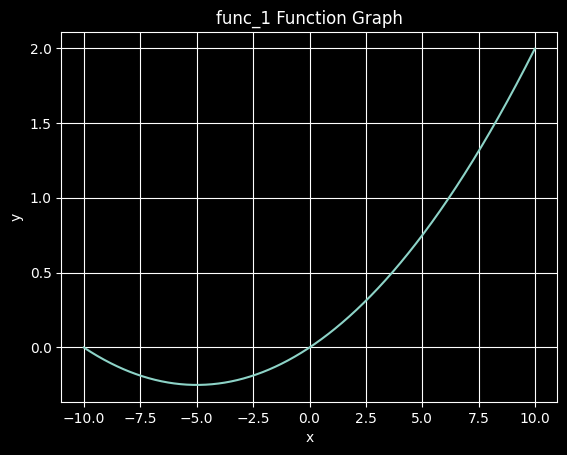

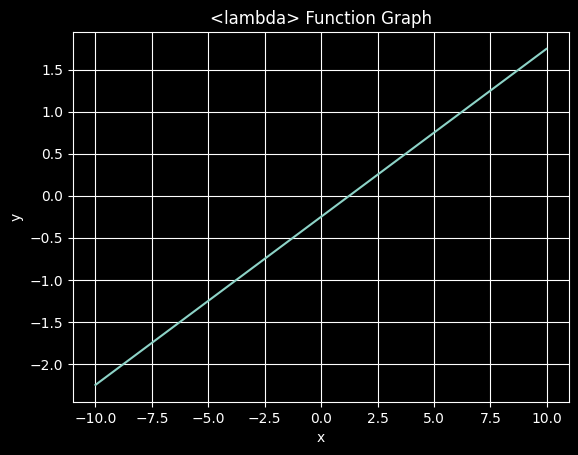

In [10]:
def func_1(x):
    return 0.01 * x ** 2 + 0.1 * x

print_function_graph(func_1,( -10, 10), 1000)
print_function_graph(tangent_line(func_1, 5, num_diff),( -10, 10), 1000)


## 편미분
- 다변수 함수에서 

In [ ]:
def num_grad(f, x):
    h = 1e-4
    grad = np.zeros_like(x)

    for idx in range(x.size):
        tmp_val = float(x[idx])
        # f(x+h)
        x[idx] = tmp_val + h    # 해당 변수만 바꿔 함수값 계산
        fxh1 = f(x)

        # f(x-h)
        x[idx] = tmp_val - h
        fxh2 = f(x)

        grad[idx] = (fxh1 - fxh2) / (2 * h)
        x[idx] = tmp_val  # 값 복원

    return grad

In [65]:
def func_2(x):
    if x.ndim == 1:
        return np.sum(x**2)
    else:
        return np.sum(x**2, axis=1)

num_grad(func_2, np.array([3.0, 4.0]))

array([6., 8.])

/tmp/ipykernel_40746/3649930619.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


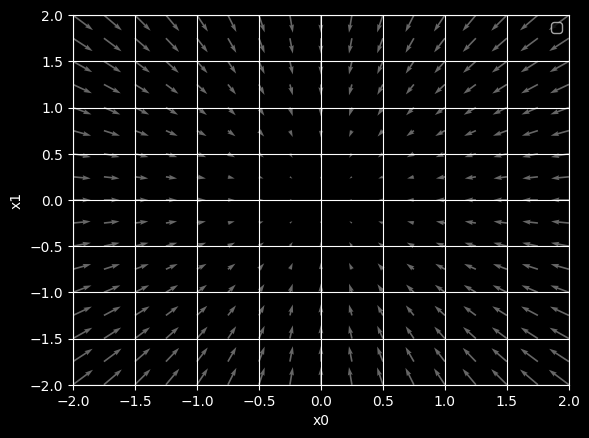

In [ ]:
def numerical_gradient(f, X):
    if X.ndim == 1:
        return num_grad(f, X)
    else:
        grad = np.zeros_like(X)

        for idx, x in enumerate(X):
            grad[idx] = num_grad(f, x)

        return grad


if __name__ == "__main__":
    x0 = np.arange(-2, 2.5, 0.25)
    x1 = np.arange(-2, 2.5, 0.25)
    X, Y = np.meshgrid(x0, x1)

    X = X.flatten()
    Y = Y.flatten()

    grad = numerical_gradient(func_2, np.array([X, Y]))

    plt.figure()
    plt.quiver(
        X, Y, -grad[0], -grad[1], angles="xy", color="#666666"
    )  # ,headwidth=10,scale=40,color="#444444")
    plt.xlim([-2, 2])
    plt.ylim([-2, 2])
    plt.xlabel("x0")
    plt.ylabel("x1")
    plt.grid()
    plt.legend()
    plt.draw()
    plt.show()